# Hypertension — Model Evaluation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix


In [3]:
model = joblib.load("../../models/hypertension_model.pkl")
X_test = pd.read_csv("../../data/processed/hypertension_X_test.csv")
y_test = pd.read_csv("../../data/processed/hypertension_y_test.csv").squeeze()


In [4]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["No Hypertension", "Hypertension"]))


                 precision    recall  f1-score   support

No Hypertension       0.93      0.91      0.92       585
   Hypertension       0.81      0.85      0.83       263

       accuracy                           0.89       848
      macro avg       0.87      0.88      0.87       848
   weighted avg       0.89      0.89      0.89       848



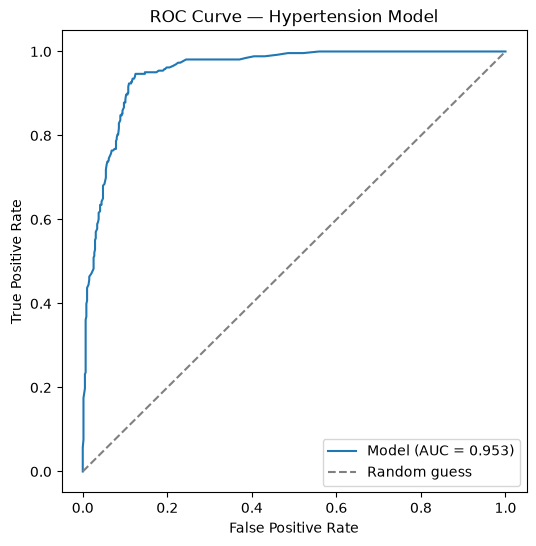

In [5]:
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Hypertension Model")
plt.legend()
plt.savefig("../../reports/figures/hypertension/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


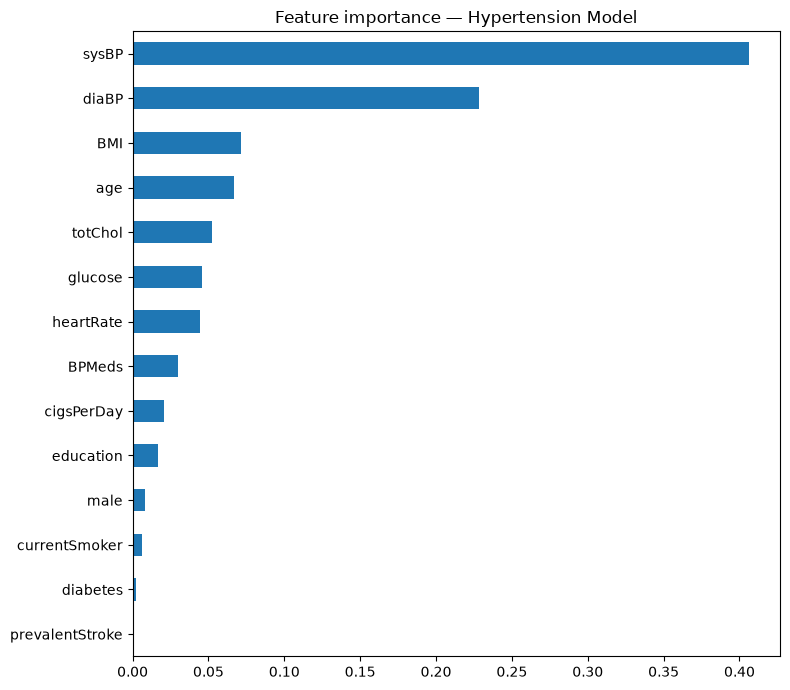

In [6]:
if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=X_test.columns)
elif hasattr(model, "coef_"):
    importances = pd.Series(model.coef_[0], index=X_test.columns)
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=True)
    plt.figure(figsize=(8, 7))
    importances.plot(kind="barh")
    plt.title("Feature importance — Hypertension Model")
    plt.tight_layout()
    plt.savefig("../../reports/figures/hypertension/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


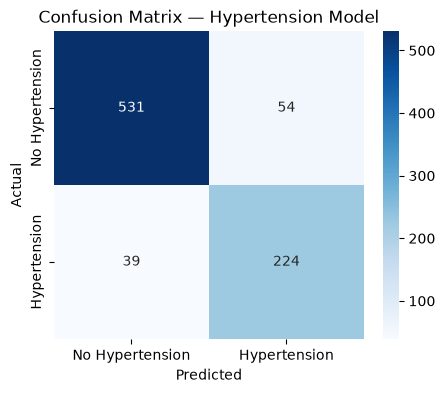

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Hypertension", "Hypertension"],
            yticklabels=["No Hypertension", "Hypertension"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Hypertension Model")
plt.savefig("../../reports/figures/hypertension/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## Next step
Hypertension pipeline complete. Move to Liver Disease next.